In [281]:
import torch
#reminder torch needs C++ to work. So make sure that's downloaded 

In [282]:
shape = (3,3)

t1 = torch.ones(shape)
t2 = torch.rand_like(t1, dtype=torch.float)

t1,t2

(tensor([[1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.]]),
 tensor([[0.7234, 0.2406, 0.4093],
         [0.9738, 0.2052, 0.7404],
         [0.8668, 0.7421, 0.1588]]))

In [283]:
print(f"Shape: {t1.shape}")
print(f"Device: {t1.device}")
print(f"Datatype: {t1.dtype}")

Shape: torch.Size([3, 3])
Device: cpu
Datatype: torch.float32


In [284]:
#autograd is the automatic gradient descent (changes weights according to the direction that would lead to a local minima)
#Keeps track of what happens to the tensor

x_data = torch.tensor([[1.,2.], [3.,4.]])
x_data = torch.tensor([[1.], [3.]], requires_grad=True)

In [285]:
a = torch.tensor(2.0, requires_grad=True)
b = torch.tensor(3.0, requires_grad=True)
x = torch.tensor(4.0, requires_grad=True)

y = a + b 
z = x*y
print(z)

tensor(20., grad_fn=<MulBackward0>)


In [286]:
# .grad_fn is a breadcrumb that tells you how a tensor was made, None means it was directly created
# z was created by multiplication
print(f"grad_fn for z: {z.grad_fn}")

# y was created by addition
print(f"grad_fn for y: {y.grad_fn}")

# a was created by user and not by an operation
print(f"grad_fn for a: {a.grad_fn}")

# loss.backward() will use these trail of breadcrumbs to get the operations

grad_fn for z: <MulBackward0 object at 0x000001AE77F87FD0>
grad_fn for y: <AddBackward0 object at 0x000001AE7FD76E60>
grad_fn for a: None


In [287]:
# * is element wise multiplications, which takes the same size and multiplies the coefficients.

a = torch.tensor([[1,2], [3,4]])
b = torch.tensor([[10,20], [30,40]])
c = a *b
c
#note how it is 1*10, 2*20, 3*30, 4*40

tensor([[ 10,  40],
        [ 90, 160]])

In [288]:
# @ is matric multiplcation. This is  2x3 @ 3x2 matrix
a = torch.tensor([[1,2], [3,4], [5,6]])
b = torch.tensor([[10,20, 30], [30,40, 60]])

c = a @ b
c

tensor([[ 70, 100, 150],
        [150, 220, 330],
        [230, 340, 510]])

In [289]:
# reduction is any operation that reduces tensor to a smaller number of elements
a = torch.tensor([[10., 20., 30.],
                  [40.,50.,60.]])
a.mean()

#dim = 0 collapes the rows
#dim = 1 collapses columns
print(a.mean(dim=0)) # matrix is 2x3. collpasing rows makes it 1x3. So a column of values is one index

print(a.mean(dim=1)) # matrix is 2x3, collapsing columns makes it 2x1. So a row of values is one index


tensor([25., 35., 45.])
tensor([20., 50.])


In [290]:
# selecting data
x = torch.arange(12).reshape(3,4)
print(x)

col_2 = x[:, 2] #gets the third column which is index 2
print(col_2)

tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])
tensor([ 2,  6, 10])


In [291]:
#argmax gets the index of the highest number 
scores = torch.tensor([[10, 0, 5, 20, 1],
                      [1, 30, 2, 5, 0]])

best_indices = torch.argmax(scores, dim=1)
best_indices

tensor([3, 1])

In [292]:
# torch.gather, get specific information. torch.gather is an optimized operation instead of a for loop
# Allows for advaanced dynamic capabilities

data = torch.tensor([
    [10, 11, 12, 13],
    [20, 21, 22, 23],
    [30, 31, 32, 33]
])

indices_to_select = torch.tensor([[2], [0], [3]])
print(torch.gather(data, dim=1, index=indices_to_select))

tensor([[12],
        [20],
        [33]])


In [293]:
# # step 1 of 5. Forward pass, model's first guess. Simple Linear Regression. y = XW + b 
# x = input
# w = weights
# b = bias

N = 10

D_in = 1
D_out = 1

X = torch.randn(N, D_in)

true_W = torch.tensor([[2.0]])
true_b = torch.tensor(1.0)
y_true = X @ true_W + true_b + torch.randn(N, D_out) * .1 # little noise
# model will never see true_W or true b. will have to discover it itself

W = torch.randn(D_in, D_out, requires_grad=True)
b = torch.randn(1, requires_grad= True)

print(f"Initial Weight W: \n {W} \n")
print(f"Initial Bias b: \n {b} \n")

y = X @ W + b

y[:3],y_true[:3] 

Initial Weight W: 
 tensor([[1.2021]], requires_grad=True) 

Initial Bias b: 
 tensor([0.9228], requires_grad=True) 



(tensor([[1.3132],
         [3.7281],
         [0.5054]], grad_fn=<SliceBackward0>),
 tensor([[1.6297],
         [5.5525],
         [0.2122]]))

In [294]:
# step 2 backward Pass. Forward pass is guess, backward pass is the autopsy. Using mean squared error to determine the error rate
error = y - y_true
squared_error = error **2
loss = squared_error.mean()
loss #loss also has a breadcrumb trail

#single command to get Pytorch to use. calculate all gradients from loss from true.
#gets the gradient of loss with respect to W and gradient of loss with respect to b
loss.backward() # python performs most critical aspect. Gets the .grad attribute
print(f"Gradient for W: \n {W.grad}")
print(f"Gradient for b: \n {b.grad}")


Gradient for W: 
 tensor([[-1.8733]])
Gradient for b: 
 tensor([0.0288])


In [295]:
# adjusting weights, training loop. Gradient descent. t1 = t0 - n Gradient(loss). t is parameters, n (eta) is learning rate, 
# torch.no_grad() don't track parameter updates
# .grad.zero_() reset gradients at each iteration
eta, epochs = .01, 100
W = torch.randn(1, 1, requires_grad=True)
b = torch.randn(1, requires_grad= True)

#training loop
for epoch in range(epochs):
    # forward pass and loss calculated
    y = X @ W + b
    y_true = X @ true_W + true_b
    loss = torch.mean((y - y_true)**2)
    
    # backward pass
    loss.backward()
    
    #update weights and bias
    with torch.no_grad():
        W -= eta*W.grad; b -= eta * b.grad
    
    # reset gradient values so it can recalculate for next loop
    W.grad.zero_(); b.grad.zero_()
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss = {loss.item()}, W = {W.item()}, b = {b.item()}")
    
print(f"Weights: {W.item()}")
print(f"Bias: {b.item()}")

Epoch 0, Loss = 11.091378211975098, W = -0.5775162577629089, b = -0.7356132864952087
Epoch 10, Loss = 7.088387966156006, W = -0.03438407927751541, b = -0.4351031184196472
Epoch 20, Loss = 4.538657188415527, W = 0.3938711881637573, b = -0.18598788976669312
Epoch 30, Loss = 2.911573886871338, W = 0.7316268086433411, b = 0.020377812907099724
Epoch 40, Loss = 1.871320366859436, W = 0.9980723857879639, b = 0.19121822714805603
Epoch 50, Loss = 1.2049930095672607, W = 1.208316445350647, b = 0.3325624465942383
Epoch 60, Loss = 0.7773749232292175, W = 1.3742564916610718, b = 0.4494360089302063
Epoch 70, Loss = 0.5024304389953613, W = 1.5052635669708252, b = 0.5460235476493835
Epoch 80, Loss = 0.3253183960914612, W = 1.6087199449539185, b = 0.6258059740066528
Epoch 90, Loss = 0.2110152244567871, W = 1.690442681312561, b = 0.6916757822036743
Weights: 1.749220848083496
Bias: 0.741057276725769


In [296]:
# torch.nn module
#prebuilt layers that froms backbone of leanrning algorithms
# torch.NN.linear gives us linear regression. Packages parameters in objects
# Parameters are a special tensor that has requires_grad= True by default
# Auto-registers with the model
#handles bookkeeping
D_in = 1
D_out = 1
linear_layer = torch.nn.Linear(in_features= D_in, out_features= D_out)
print(f"Layer's Weight: {linear_layer.weight} \n")
print(f"Layer's bias: {linear_layer.bias} \n")

y_nn = linear_layer(X)

print(f"Output of nn.Linear (first 3 rows): \n {y_nn[:3]}")

Layer's Weight: Parameter containing:
tensor([[0.0959]], requires_grad=True) 

Layer's bias: Parameter containing:
tensor([0.6846], requires_grad=True) 

Output of nn.Linear (first 3 rows): 
 tensor([[0.7157],
        [0.9084],
        [0.6513]], grad_fn=<SliceBackward0>)


In [297]:
# Activation functions make it non-linear 
# NN.ReLu(), if input is negative, make it 0
# nn.GELU() is Gaussian error linear unit. A smoother, gently curving version of ReLu
# nn.softmax() convert logits (raw model scores) into probability distribution. 
softmax = torch.nn.Softmax(dim=-1)
logits = torch.tensor([[1.0, 3.0, 0.5, 1.5], [-1.0, 2.0, 1.0, 0.0]])
probabilities = softmax(logits)
print(f"Output probabilities: \n {probabilities}\n")
print(f"Sum probabilities: {probabilities[0].sum()}\n")

Output probabilities: 
 tensor([[0.0939, 0.6942, 0.0570, 0.1549],
        [0.0321, 0.6439, 0.2369, 0.0871]])

Sum probabilities: 1.0



In [298]:
#for building blocks of GPT, LLAMA and Gemini
#nn.embedding, turns words -> numbers 
vocab_size = 10 # 10 unique words
embedding_dim = 3 # Represent each word with a 3D vector

embedding_layer = torch.nn.Embedding(vocab_size, embedding_dim)

input_ids = torch.tensor([[1, 5, 0, 8]])
word_vectors = embedding_layer(input_ids)

print(word_vectors)
    

tensor([[[ 0.3806, -0.0220, -0.8170],
         [-0.2653, -0.6737,  0.5291],
         [ 1.0873,  0.3353, -0.4042],
         [-0.1035,  1.1476,  1.1388]]], grad_fn=<EmbeddingBackward0>)


In [299]:
#nn.layernorm. Normalizes ranges so that the mean should be around 0
norm_layer = torch.nn.LayerNorm(normalized_shape=3)
input_features = torch.tensor([[[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]]])
normalized_features = norm_layer(input_features)

print(normalized_features)
print(f"Mean : {normalized_features.mean(dim=-1)}")
print(f"Std Dev : {normalized_features.std(dim=-1)}")

tensor([[[-1.2247,  0.0000,  1.2247],
         [-1.2247,  0.0000,  1.2247]]], grad_fn=<NativeLayerNormBackward0>)
Mean : tensor([[0., 0.]], grad_fn=<MeanBackward1>)
Std Dev : tensor([[1.2247, 1.2247]], grad_fn=<StdBackward0>)


In [300]:
#nn.dropout prevents overfitting by taking out outliers. Randomly zeros neruons during trainings  
drop_out = torch.nn.Dropout(p =.5)
input_tensor = torch.ones(1, 10)

#activate dropout for training
drop_out.train()
output_during_train = drop_out(input_tensor)

#deactivate dropout for pevaluation and prediction
drop_out.eval()
output_during_eval = drop_out(input_tensor)

# Half the numbers are zeroed, the others are scaled up to match the valeus
print(f"Output during training: {output_during_train}")
print(f"Output during evaluation: {output_during_eval}")

Output during training: tensor([[0., 0., 2., 2., 0., 0., 0., 2., 0., 2.]])
Output during evaluation: tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]])


In [301]:
# nn.Module to organize module (instruction booklet and baseplate) for structure and how bricks connect
# torch.optim adjusts all parameters according to the instructions from gradients
# clean standard and scalable

#blueprint
# 1. inherit torch.nn.Module
# 2. __init__: define layers
# 3. forward: connect layers

#creation of a linear regression model
import torch.nn as nn
class LinearRegressionModel(nn.Module):
    #these will define layers of a neural network
    # each line of code represents a 
    def __init__(self, in_features, out_features):
        super().__init__()
        self.linear_layer = nn.Linear(in_features, out_features)
    
    #connects layers / defines how to calculate output as input for the next layer
    #
    def forward(self, x):
        #data flow can look like this
        # x = self.layer1(x)
        # x = self.activation(x)
        # x = self.layer2(x)
        # this will transform the input data, x, through layer 1, activation, and layer 2. Each layer will
        # contain the breadcrumb trail. Allowing for the  
        return self.linear_layer(x)
    

linReg = LinearRegressionModel(in_features= 1, out_features= 1)
print(linReg)

LinearRegressionModel(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)


In [302]:
# creates gradient descent for learning algorithm
import torch.optim as optim

learning_rate = 0.01

optimizer = optim.Adam(linReg.parameters(), lr=learning_rate)

loss_fn = nn.MSELoss() # calculates loss function as Mean Squared Error loss

In [303]:
#training loop, 3 line mantra

# 1.
# optimizer.zero_grad()

# #2
# loss.backward()

# #3
# optimizer.step()

#final training loop

epochs = 100

for epoch in range(epochs):
    y = linReg(X) #puts input data through model
    
    # y_true are the expected outputs whereas y is the model's output
    loss = loss_fn(y, y_true)
    
    optimizer.zero_grad() #resets gradients as it's about to calculate new gradient adjustments
    loss.backward() # gets the delta errors at each neurons
    optimizer.step() # adjust weights and bias for every neuron according to loss
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss = {loss.item()}")


print(linReg.linear_layer.weight.item())
print(linReg.linear_layer.bias.item())

Epoch 0, Loss = 7.681694984436035
Epoch 10, Loss = 7.076725959777832
Epoch 20, Loss = 6.511723518371582
Epoch 30, Loss = 5.976527214050293
Epoch 40, Loss = 5.47350549697876
Epoch 50, Loss = 5.002279758453369
Epoch 60, Loss = 4.562255859375
Epoch 70, Loss = 4.152381420135498
Epoch 80, Loss = 3.771482467651367
Epoch 90, Loss = 3.41827130317688
0.39176398515701294
0.9351140856742859


5 steps of neural network
1. Create model / layers
2. calculate loss function
3. optimizer.zero_grad()
4. loss.backward()
5. optimizer.step()

In [ ]:
#model of 2 hidden layer to determine iris species on 4 inputs 

import torch.nn.functional as F

class IrisDetector(nn.Module):
    def __init__(self, in_features = 4, h1=8, h2= 9, out_feature = 3):
        super().__init__()
        self.fc1 = nn.Linear(in_features, h1)
        self.fc2 = nn.Linear(h1, h2)
        self.out = nn.Linear(h2, out_feature)
        
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        
        x = self.out(x)
        
        return x

In [305]:
torch.manual_seed(41)

model = IrisDetector()


In [306]:
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline

In [307]:

df = pd.read_csv("iris-data.csv")

df['class'] = df['class'].replace('Iris-setosa', 0)
df['class'] = df['class'].replace('Iris-versicolor', 1)
df['class'] = df['class'].replace('Iris-virginica', 2)
type(df['class'][1])

int

In [308]:
X = df.drop('class', axis =1)
y = df['class'].astype('int64')

X = X.values
y = y.values

In [309]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state= 41)
X_train[:3]


array([[5.7, 2.6, 3.5, 1. ],
       [6.5, 2.8, 4.6, 1.5],
       [4.9, 2.5, 4.5, 1.7]])

In [310]:
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

In [311]:
#measure error
criterion = nn.CrossEntropyLoss()
#choose Adam optimizer
lr = 0.01
optimizer = optim.Adam(model.parameters(), lr= lr)

In [312]:
#training model
epochs = 250
losses = []

for epoch in range(epochs):
    y_pred = model.forward(X_train)
    
    loss = criterion(y_pred, y_train)
    losses.append(loss.detach().numpy())
    
    #print every 10 epochs
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} and loss: {loss}")
        
    #back propagation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    

Epoch: 0 and loss: 1.1251550912857056


Epoch: 10 and loss: 1.0096259117126465
Epoch: 20 and loss: 0.8157405257225037
Epoch: 30 and loss: 0.585706353187561
Epoch: 40 and loss: 0.3999636471271515
Epoch: 50 and loss: 0.26768800616264343
Epoch: 60 and loss: 0.17942363023757935
Epoch: 70 and loss: 0.12151691317558289
Epoch: 80 and loss: 0.0860118493437767
Epoch: 90 and loss: 0.06520850956439972
Epoch: 100 and loss: 0.052865754812955856
Epoch: 110 and loss: 0.04508380591869354
Epoch: 120 and loss: 0.0397995188832283
Epoch: 130 and loss: 0.03597070649266243
Epoch: 140 and loss: 0.0329371802508831
Epoch: 150 and loss: 0.0304193664342165
Epoch: 160 and loss: 0.02679518237709999
Epoch: 170 and loss: 0.023382510989904404
Epoch: 180 and loss: 0.020531879737973213
Epoch: 190 and loss: 0.018495608121156693
Epoch: 200 and loss: 0.016802625730633736
Epoch: 210 and loss: 0.015520296059548855
Epoch: 220 and loss: 0.014496718533337116
Epoch: 230 and loss: 0.013446054421365261
Epoch: 240 and loss: 0.012675682082772255


Text(0.5, 0, 'Epoch')

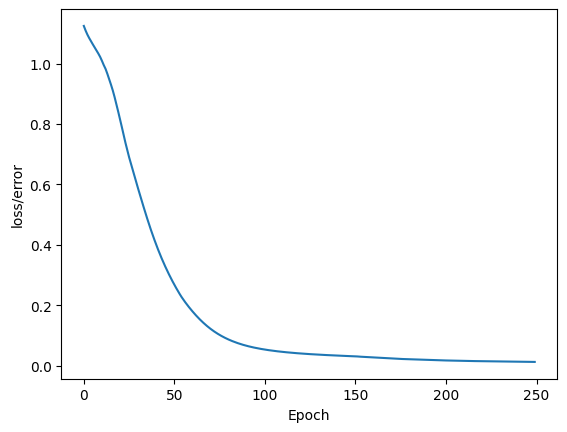

In [313]:
plt.plot(range(epochs), losses)
plt.ylabel("loss/error")
plt.xlabel('Epoch')

In [314]:
with torch.no_grad(): # turns off back propagation 
    y_eval = model.forward(X_test) #X_test, y_eval are predictions
    loss = criterion(y_eval, y_test)
    print(loss)
    
    #loss of test set is p.1315 when the training set is .065. Very different

tensor(0.2335)


In [315]:
correct = 0
with torch.no_grad():
    for i, data in enumerate(X_test):
        y_val = model.forward(data)
        
        #print(f"{i+1}.) {str(y_val)} \t {y_test[i]}")
        
        # correct or not
        if y_val.argmax().item() == y_test[i]:
            #print("correct")
            correct +=1
        else:
            print(f"Predicted {y_val.argmax().item()}, but should be {y_test[i]} for these arguments {X_test[i].numpy()}")

print(f"{correct} are correct")

Predicted 1, but should be 2 for these arguments [6.3 2.8 5.1 1.5]
Predicted 2, but should be 1 for these arguments [6.  2.7 5.1 1.6]
28 are correct
